In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
import pickle
from pathlib import Path

import sys
sys.path.append('../../')

import phys_ml.visualization.vertex_visualization as vertvis
from phys_ml.analysis.vertex import *
from phys_ml.evaluation import vertex as verteval
from phys_ml.load_data.vertex import *
from phys_ml.trainer.vertex import *
from phys_ml.util import slurm_generate

In [ ]:
# back_up existing info_files
info_fn = 'eval_info_test.pkl'
verteval.backup_info(info_fn)

## dev

In [3]:
!pip show lightning

Name: lightning
Version: 2.4.0
Summary: The Deep Learning framework to train, deploy, and ship AI products Lightning fast.
Home-page: https://github.com/Lightning-AI/lightning
Author: Lightning AI et al.
Author-email: pytorch@lightning.ai
License: Apache-2.0
Location: C:\Users\Sebastian\venv\ml24_1\Lib\site-packages
Requires: fsspec, lightning-utilities, packaging, pytorch-lightning, PyYAML, torch, torchmetrics, tqdm, typing-extensions
Required-by: 


In [4]:
!pip show torch

Name: torch
Version: 2.4.0+cu118
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3
Location: C:\Users\Sebastian\venv\ml24_1\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: lightning, pytorch-lightning, torchaudio, torchmetrics, torchvision


In [ ]:
###############    TEST RUN    ################
info_fn = 'eval_info_test.pkl'
info_test = verteval.load_info_dict(info_fn)
trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                            subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                            config_kwargs={'path_train': '../../../frgs_6d', 'hidden_dims': [128, 64, 32],
                                    	   'sample_count_per_vertex': 2000, 'test_ratio': 0.33, 'epochs': 5,
                                           'subset': 3, 'subset_shuffle': False})

In [ ]:
verteval.eval_train(trainer, info_test, info_fn, [128, 64, 32])

## slurm

In [ ]:
# config
base_dir = '/gpfs/data/fs71925/shepp123/'
sample_count = int((2000 * 576 * 3) / (24 * 6))
hidden_dims = [128, 64, 32]
trainer_kwargs = {
    'config_name': 'confmod_auto_encoder.json', 
    'subconfig_name': 'AUTO_ENCODER_VERTEX_24X6', 
    'config_kwargs': {
        'path_train': base_dir + 'frgs_6d',
        'hidden_dims': hidden_dims,
        'epochs': 100,
        'sample_count_per_vertex': sample_count, 
        'test_ratio': 0.2, 
        'subset': -1, 
        'subset_shuffle': False, 
        'devices': 'auto', 
        'device_type': 'gpu', 
        'num_dataloader_workers': 8, 
        'batch_size': 2048,
    }
}
slurm_options = slurm_generate.SlurmOptions(qos='zen3_0512_a100x2', time='00:10:00')
slurm_kwargs = {'project_name': 'vertex_24x6', 'pyenv_dir': base_dir + 'pyenv', 
                'trainer': 'vertex.VertexTrainer24x6', 'slurm_options': slurm_options, 'trainer_kwargs': trainer_kwargs}

In [ ]:
# test run
slurm_options_dev = slurm_generate.SlurmOptions(qos='zen3_0512_a100x2_devel', time='00:10:00')
slurm_generate.create(project_name='vertex_24x6', script_name='vsc_test', 
                      pyenv_dir= base_dir + 'PhysML/.venv', slurm_options=slurm_options_dev, 
                      trainer='vertex.VertexTrainer24x6', trainer_kwargs=trainer_kwargs)

In [ ]:
# 02: high samples, high epochs
trainer_kwargs['config_kwargs']['sample_count_per_vertex'] = sample_count
trainer_kwargs['config_kwargs']['batch_size'] = 8192
trainer_kwargs['config_kwargs']['epochs'] = 1000
trainer_kwargs['config_kwargs']['num_dataloader_workers'] = 15
slurm_options.time = '01:30:00'
slurm_generate.create(script_name='s24000_e1000', **slurm_kwargs)
# job-id:
# dir:

In [ ]:
# 02: high samples, low epochs
trainer_kwargs['config_kwargs']['sample_count_per_vertex'] = sample_count
trainer_kwargs['config_kwargs']['batch_size'] = 8192
trainer_kwargs['config_kwargs']['epochs'] = 100
trainer_kwargs['config_kwargs']['num_dataloader_workers'] = 15
slurm_options.time = '00:15:00'
slurm_generate.create(script_name='s24000_e100', **slurm_kwargs)
# job-id:
# dir:

In [ ]:
# 02: low samples, high epochs
trainer_kwargs['config_kwargs']['sample_count_per_vertex'] = 2000
trainer_kwargs['config_kwargs']['batch_size'] = 4096
trainer_kwargs['config_kwargs']['epochs'] = 1000
trainer_kwargs['config_kwargs']['num_dataloader_workers'] = 8
slurm_options.time = '00:10:00'
slurm_generate.create(script_name='s2000_e1000', **slurm_kwargs)
# job-id:
# dir:

In [ ]:
# 02: low samples, low epochs
trainer_kwargs['config_kwargs']['sample_count_per_vertex'] = 2000
trainer_kwargs['config_kwargs']['batch_size'] = 4096
trainer_kwargs['config_kwargs']['epochs'] = 100
trainer_kwargs['config_kwargs']['num_dataloader_workers'] = 8
slurm_options.time = '00:05:00'
slurm_generate.create(script_name='s2000_e100', **slurm_kwargs)
# job-id:
# dir:

In [ ]:
# 03: [128, 64, 32]
trainer_kwargs['config_kwargs']['sample_count_per_vertex'] = ?
trainer_kwargs['config_kwargs']['batch_size'] = ?
trainer_kwargs['config_kwargs']['epochs'] = ?
trainer_kwargs['config_kwargs']['hidden_dims'] = [128, 64, 32]
trainer_kwargs['config_kwargs']['num_dataloader_workers'] = ?
slurm_options.time = ?
slurm_generate.create(script_name='128_64_32', **slurm_kwargs)
# job-id:
# dir:

In [ ]:
# 03: [128, 64, 32, 16]
trainer_kwargs['config_kwargs']['hidden_dims'] = [128, 64, 32, 16]
slurm_options.time = ?
slurm_generate.create(script_name='128_64_32_16', **slurm_kwargs)
# job-id:
# dir:

In [ ]:
# 03: [128, 64, 32, 8]
trainer_kwargs['config_kwargs']['hidden_dims'] = [128, 64, 32, 8]
slurm_generate.create(script_name='128_64_32_8', **slurm_kwargs)
# job-id:
# dir:

In [ ]:
# 03: [128, 32, 16, 4]
trainer_kwargs['config_kwargs']['hidden_dims'] = [128, 32, 16, 4]
slurm_generate.create(script_name='128_32_16_4', **slurm_kwargs)
# job-id:
# dir:

# 01 Full training

* training on all vertices
* 24,000 samples -> with smaller sample-vectors (size=144) of the 24^6-vertex this results in same amount of data points as training on 576^3-vertex with 2000 samples

In [ ]:
info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
sample_count = int((2000 * 576 * 3) / (24 * 6))
config_kwargs={'path_train': '../../../frgs_6d', 
               'hidden_dims': [128, 64, 32],
               'epochs': 100,
               'sample_count_per_vertex': sample_count, 
               'test_ratio': 0.2, 
               'subset': None, 
               'subset_shuffle': False, 
               'devices': 'auto', 
               'num_dataloader_workers': 4, 
               'strategy': 'auto', 
               'batch_size': 2048}


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## train

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 64, 32])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07\\version_0'

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 64, 32, 16])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07\\version_1'

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 64, 32, 8])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07\\version_2'

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 32, 16, 4])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07\\version_3'

## evaluate prediction

In [ ]:
test_file = 'tp0.020000_mu0.080000.h5'
test_file3d = '../../../frgs/' + test_file
test_file6d = '../../../frgs_6d/' + test_file

info = verteval.load_info_dict(info_fn)

vertex3 = AutoEncoderVertexDataset.load_from_file(test_file3d)
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)

keys = [f'n={x['latent_dim']}' for x in info]
trainer = init_trainer(device_type='cpu')

i = 18
axis = trainer.config.construction_axis
k, other_k = (axis + 1) // 2, 3
slice_idx_3d = i * 24 + i
nrows, ncols = 2, 3

### predict 24x24 slice

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_0/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_0/checkpoints\last.ckpt
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\loops\prediction_loop.py:255: predict returned None if it was on purpose, ignore this warning...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_1/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_1/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_2/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_2/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_3/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_3/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=32: RMSE=0.4388
   latent_dim=16: RMSE=0.4827
   latent_dim=8: RMSE=0.4984
   latent_dim=4: RMSE=1.2742


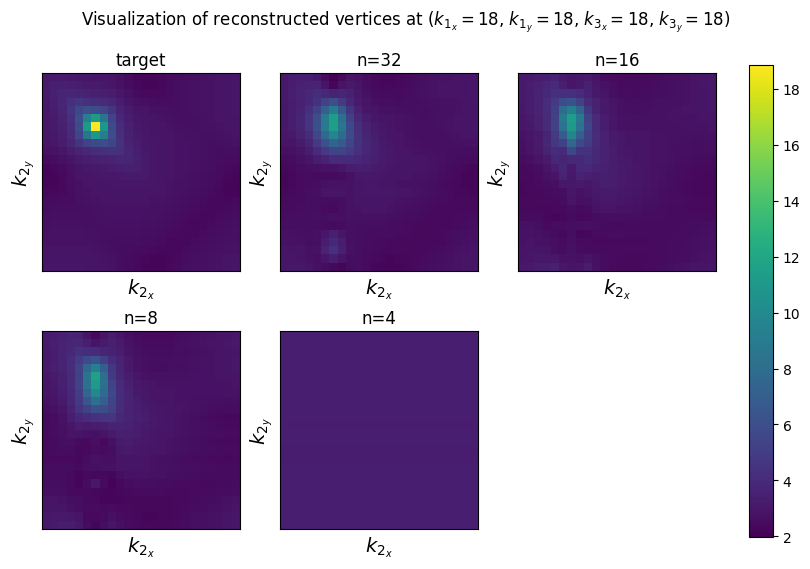

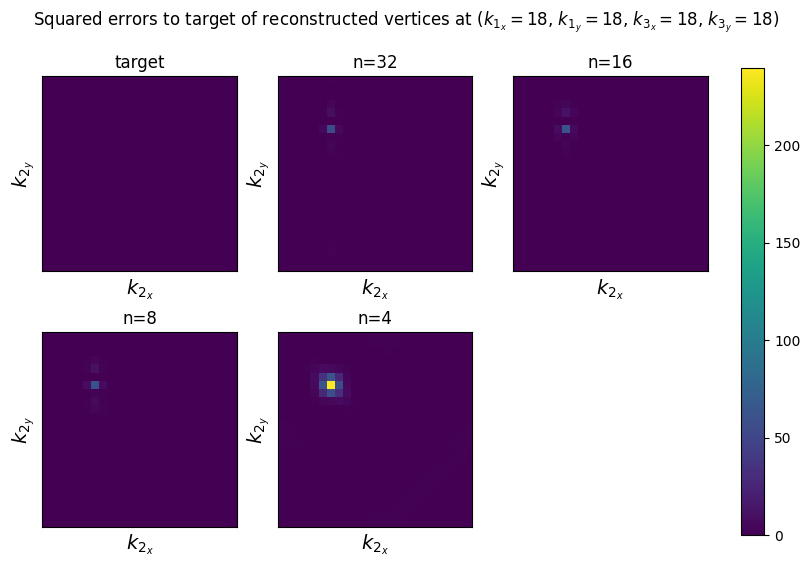

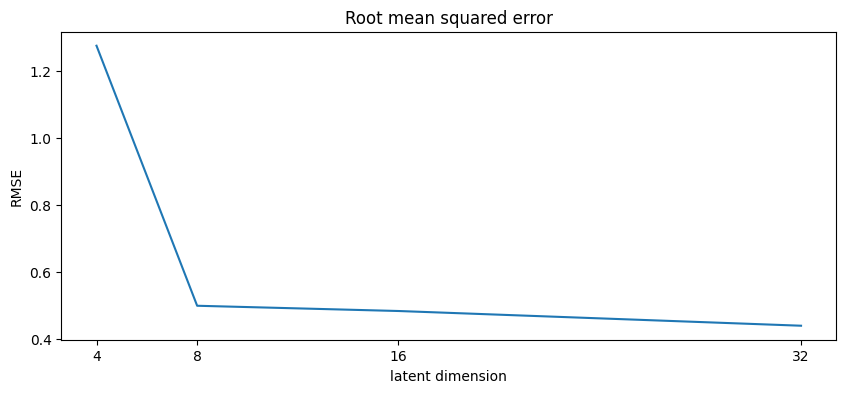

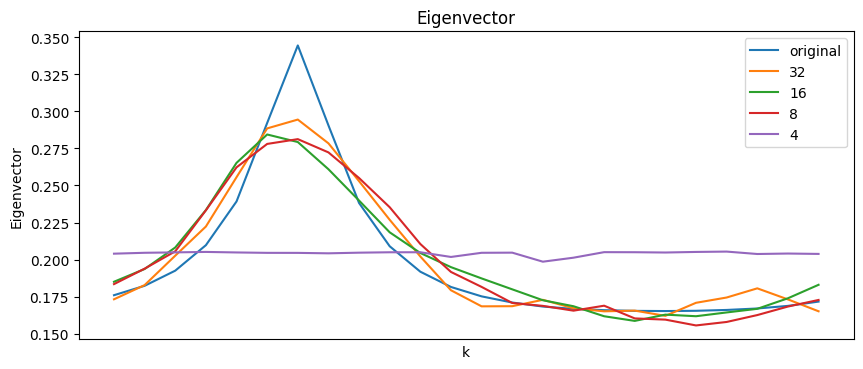

In [ ]:
# RESULTS FOR 2-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i, i, i), axis, keys, nrows, ncols, 
                             trainer.predict_slice2d, fixed_idcs=(i, i, i, i))

### predict 576x576 slice

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_0/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_0/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_1/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_1/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_2/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_2/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_3/checkpoints\last.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_3/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=32: RMSE=0.4710
   latent_dim=16: RMSE=0.5280
   latent_dim=8: RMSE=0.5295
   latent_dim=4: RMSE=1.6256


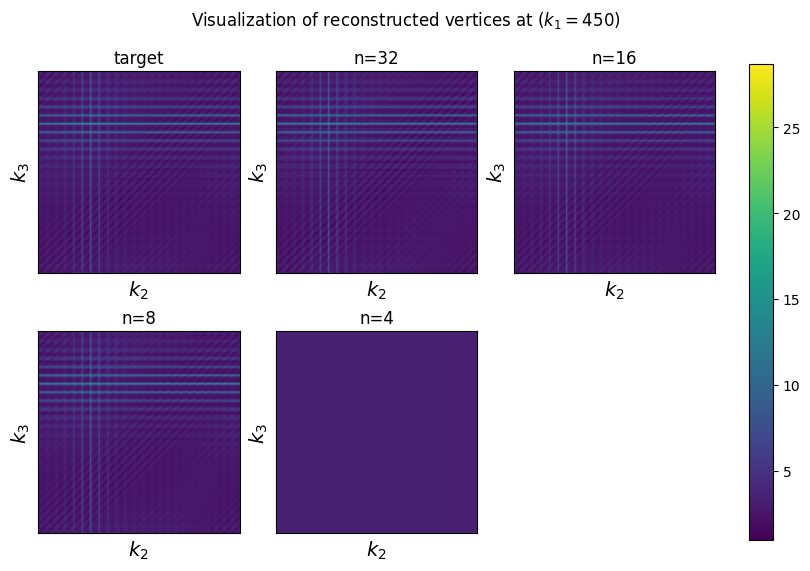

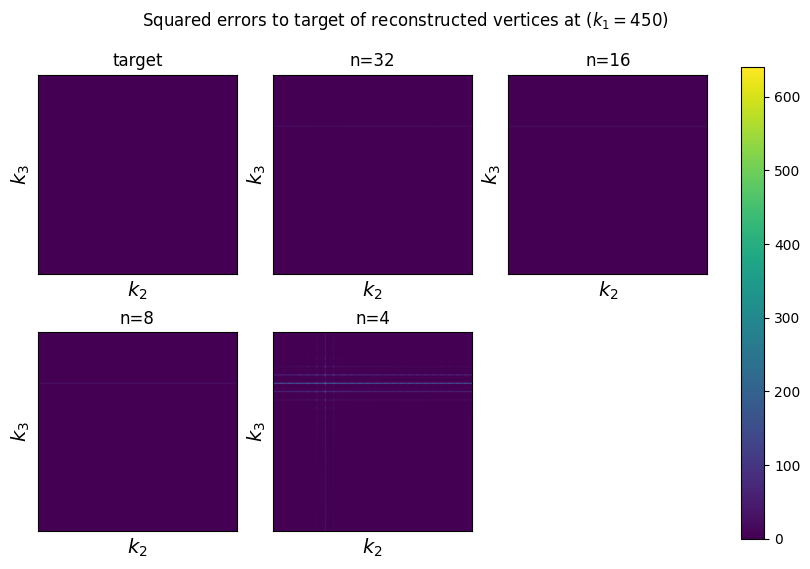

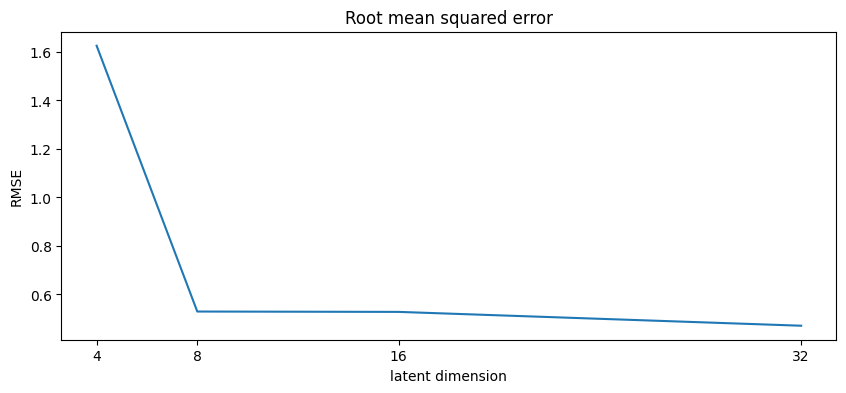

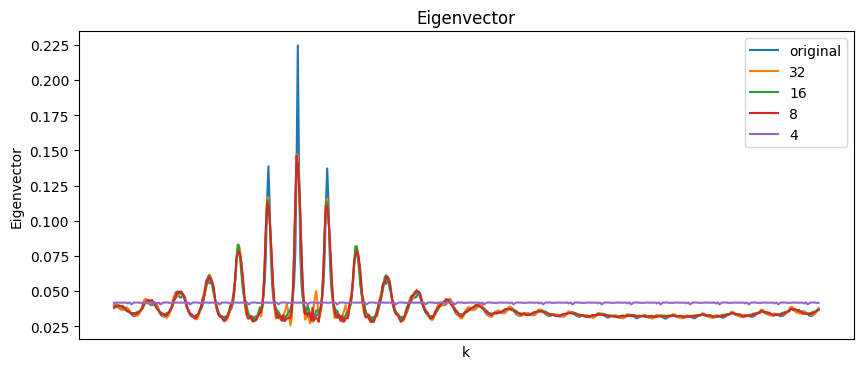

In [ ]:
# RESULTS FOR 4-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i), (k, other_k), keys, nrows, ncols, 
                             trainer.predict_slice4d, fixed_idcs=(i, i), other_k=other_k)

### predict full vertex

In [44]:
sample_count = int((2000 * 576 * 3) / (24 * 6))
trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                            subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                            config_kwargs={'path_train': '../../../frgs_6d', 
                                        'hidden_dims': [128, 64, 32],
                                        'epochs': 100,
                                        'sample_count_per_vertex': sample_count, 
                                        'test_ratio': 0.2, 
                                        'subset': None, 
                                        'subset_shuffle': False, 
                                        'devices': 'auto', 
                                        'device_type': 'cpu', 
                                        'num_dataloader_workers': 4, 
                                        'strategy': 'auto', 
                                        'batch_size': 2048})

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_0/checkpoints\last.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_0/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_1/checkpoints\last.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_1/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_2/checkpoints\last.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_2/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_3/checkpoints\last.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_3/checkpoints\last.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=32: RMSE=0.4167
   latent_dim=16: RMSE=0.4703
   latent_dim=8: RMSE=0.5316
   latent_dim=4: RMSE=1.6466


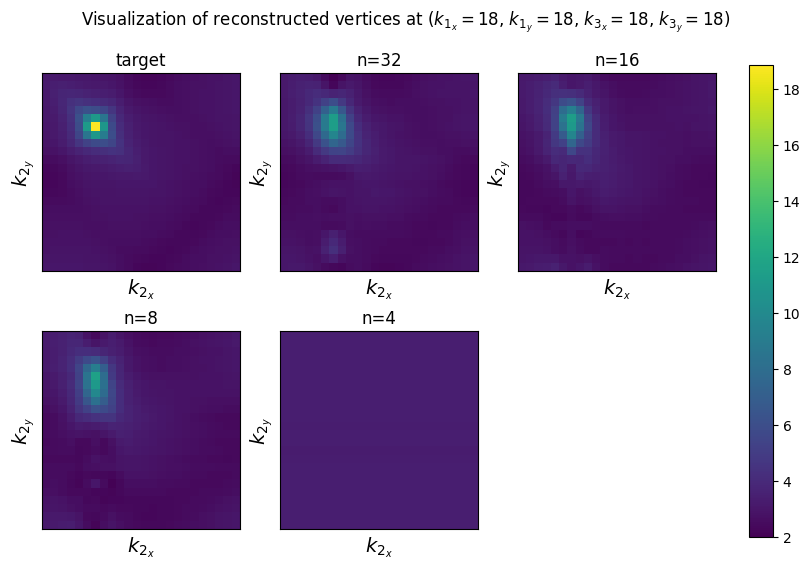

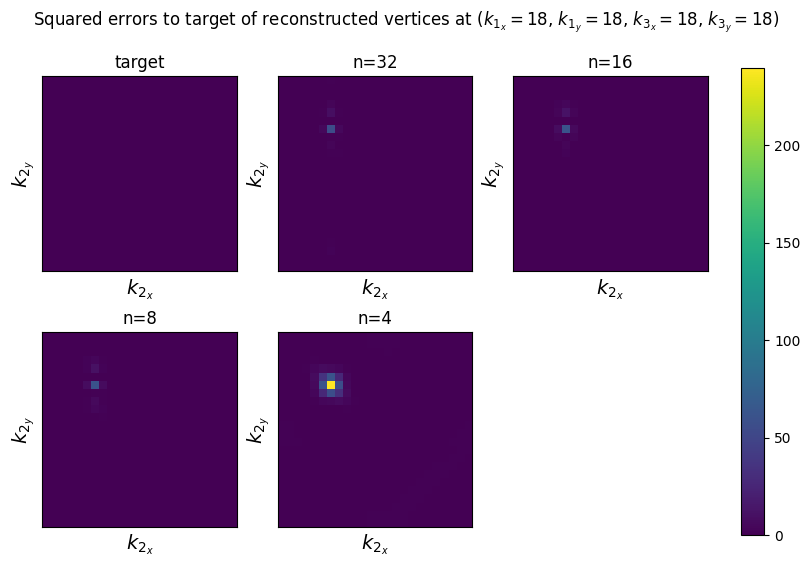

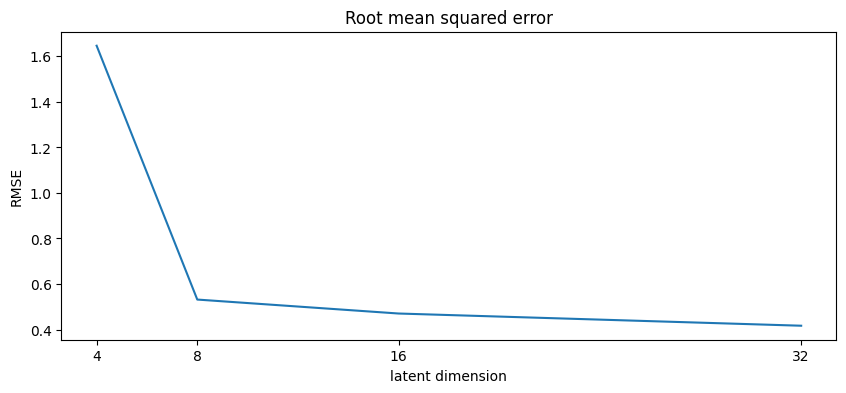

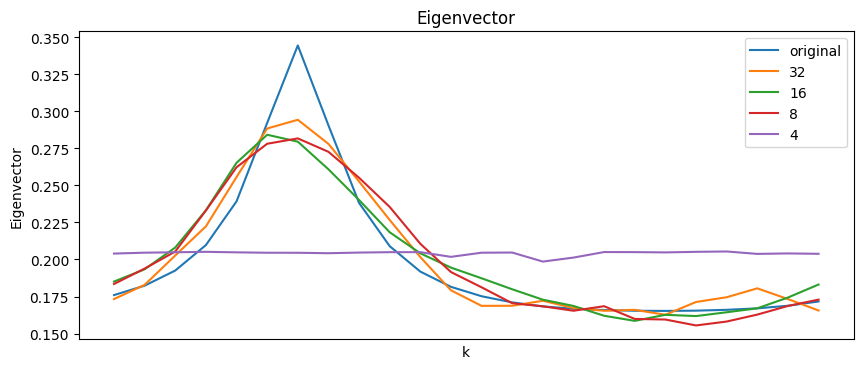

In [ ]:
# RESULTS FOR 6-DIMENSIONAL PREDICTION
# for 6d-data
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

RESULTS:
   latent_dim=32: RMSE=0.4167
   latent_dim=16: RMSE=0.4703
   latent_dim=8: RMSE=0.5316
   latent_dim=4: RMSE=1.6466


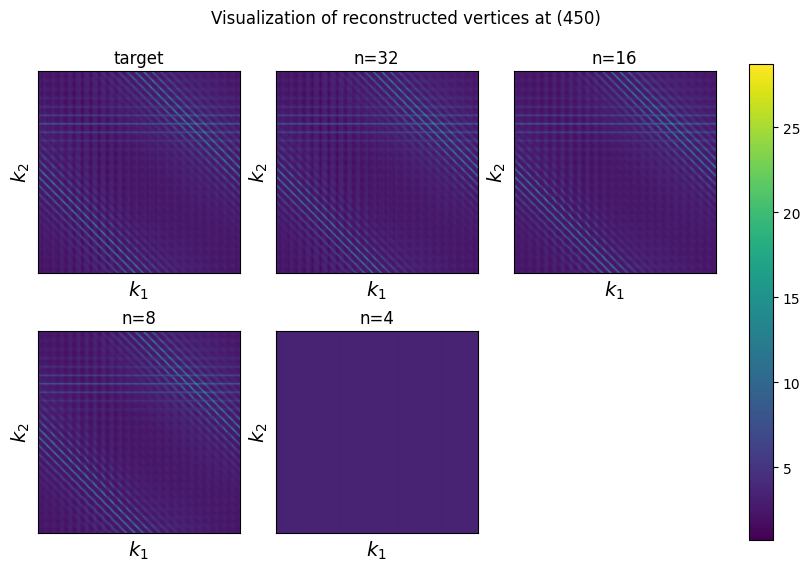

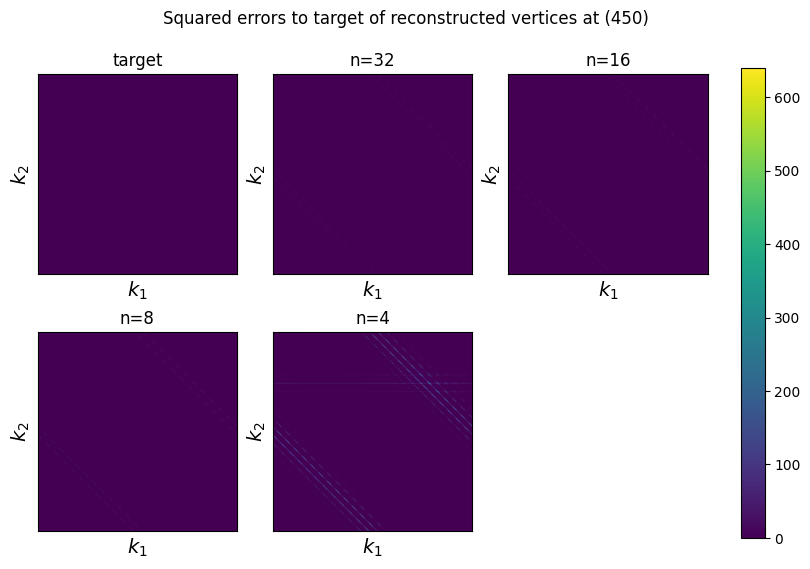

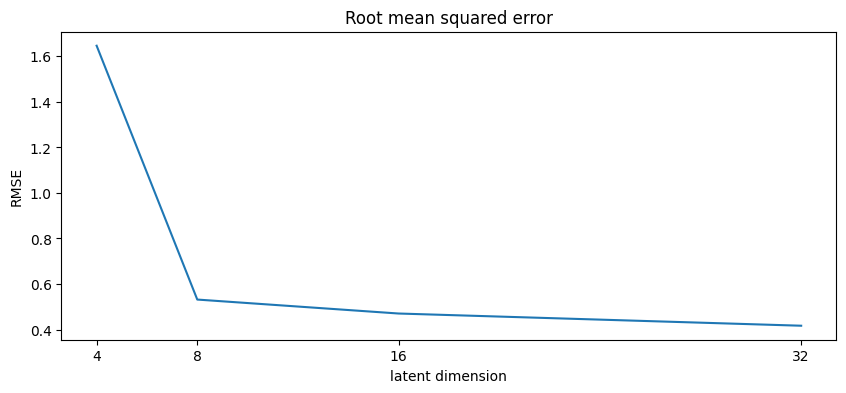

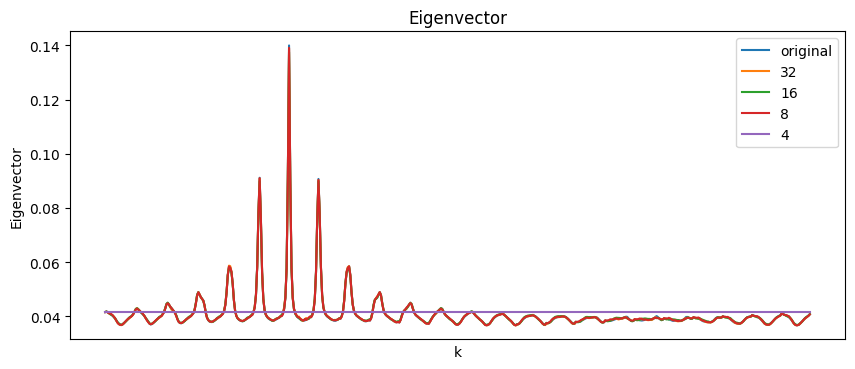

In [ ]:
# for 3d-data
slice_at = slice_idx_3d
verteval.evaluate_and_report(info, test_file3d, trainer, vertex3, slice_at, axis, keys, nrows, ncols, 
                             load_func=trainer.load_prediction)

## correlation analysis

load files:   0%|          | 0/51 [00:00<?, ?it/s]

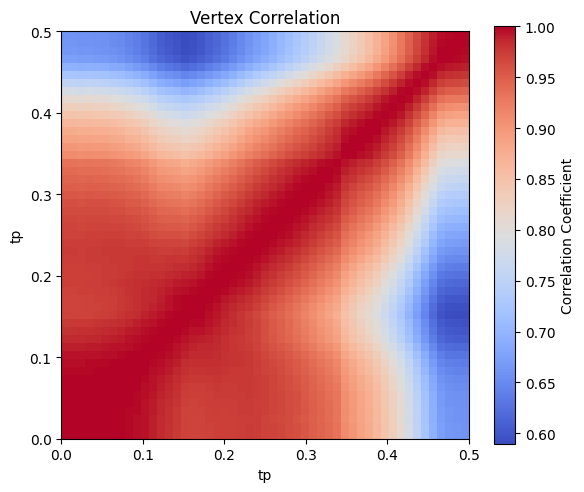

In [ ]:
cor_mat = verteval.vertex_correlation('../../../frgs_6d', pre_load_vertices=True)
vertvis.plot_correlation(cor_mat, "Vertex Correlation")

## phase classification

In [3]:
info_fn = 'eval_info.pkl'
info = verteval.load_info_dict(info_fn)

In [5]:
pc = PhaseClassification('../../../frgs_6d', info[1]['save_path'], samples_per_vertex=2000, test_size=0.1)
pc.train()

Load data:   0%|          | 0/45 [00:00<?, ?it/s]

Fit models:   0%|          | 0/2 [00:00<?, ?it/s]

[LibSVM]...........................
*..*.
*
optimization finished, #iter = 30072
obj = -42421.853805, rho = 2.930341
nSV = 46968, nBSV = 46628
......................
*...*
optimization finished, #iter = 25221
obj = -32915.630153, rho = 2.875136
nSV = 37873, nBSV = 37573
.............................
*..*.*
optimization finished, #iter = 32032
obj = -45679.913812, rho = -0.182601
nSV = 48421, nBSV = 48043
Total nSV = 79517


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 128 concurrent workers.
[Parallel(n_jobs=-1)]: Done  47 out of 100 | elapsed:    1.2s remaining:    1.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.5s finished


In [20]:
pc = PhaseClassification('../../../frgs_6d', info[1]['save_path'], samples_per_vertex=2000, test_size=0.1)

Load data:   0%|          | 0/45 [00:00<?, ?it/s]

Predict with sampling from known vertices:   0%|          | 0/2 [00:00<?, ?it/s]

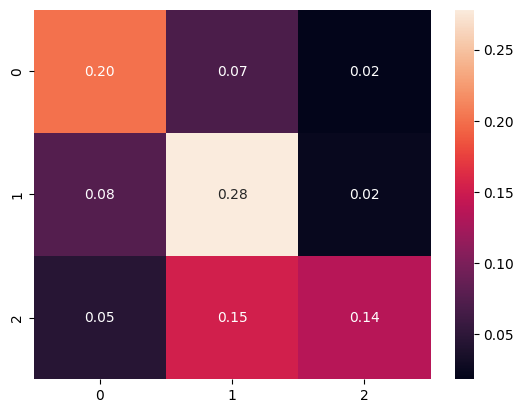

[Parallel(n_jobs=100)]: Using backend ThreadingBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   2 out of 100 | elapsed:    0.0s remaining:    0.8s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    0.0s finished


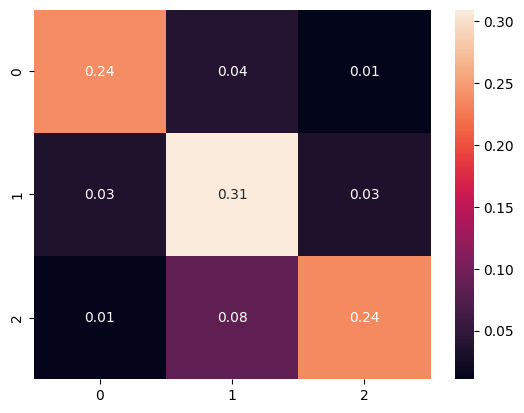

Predict with sampling from new vertices:   0%|          | 0/2 [00:00<?, ?it/s]

Load data:   0%|          | 0/6 [00:00<?, ?it/s]

/gpfs/opt/sw/jupyterhub/envs/conda/vsc5/jupyterhub-llm-training-v4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


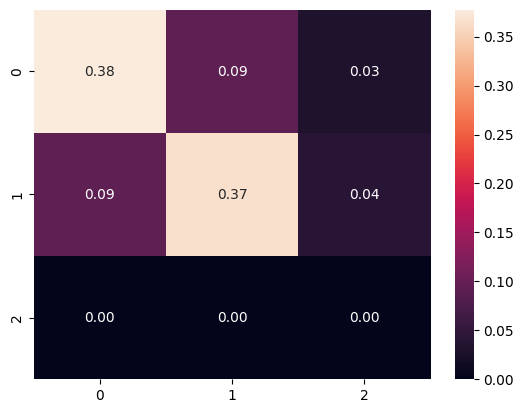

Load data:   0%|          | 0/6 [00:00<?, ?it/s]

[Parallel(n_jobs=100)]: Using backend ThreadingBackend with 100 concurrent workers.
[Parallel(n_jobs=100)]: Done   2 out of 100 | elapsed:    0.0s remaining:    0.7s
[Parallel(n_jobs=100)]: Done 100 out of 100 | elapsed:    0.0s finished
/gpfs/opt/sw/jupyterhub/envs/conda/vsc5/jupyterhub-llm-training-v4/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


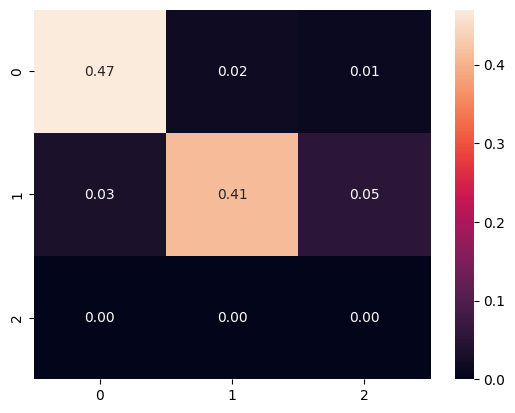

{'sampling from new vertices': {'SVC': ({'acc': np.float64(0.7446666666666666),
    'prec': 0.7446666666666667,
    'rec': 0.7446666666666667,
    'f1': 0.7446666666666667},
   array([[0.3775    , 0.09175   , 0.03075   ],
          [0.09241667, 0.36716667, 0.04041667],
          [0.        , 0.        , 0.        ]])),
  'RandomForestClassifier': ({'acc': np.float64(0.8819166666666667),
    'prec': 0.8819166666666667,
    'rec': 0.8819166666666667,
    'f1': 0.8819166666666667},
   array([[0.46966667, 0.01741667, 0.01291667],
          [0.03441667, 0.41225   , 0.05333333],
          [0.        , 0.        , 0.        ]]))},
 'sampling from known vertices': {'SVC': ({'acc': np.float64(0.6128227775286599),
    'prec': 0.6146146146146146,
    'rec': 0.6146146146146146,
    'f1': 0.6146146146146146},
   array([[0.201001  , 0.06936937, 0.01851852],
          [0.07537538, 0.27807808, 0.02432432],
          [0.04504505, 0.15275275, 0.13553554]])),
  'RandomForestClassifier': ({'acc': np.float

In [21]:
model_scores = pc.evaluate_classifiers(print_conf_mat=True)
model_scores

In [22]:
with open(f'phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)

# 02 Training extent comparison

* excluding last vertex for testing
* compare different sample sizes and number of epochs

In [3]:
info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32]
sample_count = int((2000 * 576 * 3) / (24 * 6))
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'hidden_dims': hidden_dims,
                 'epochs': 100,
                 'sample_count_per_vertex': sample_count, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': False, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 4, 
                 'strategy': 'auto', 
                 'batch_size': 2048}


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## train

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, hidden_dims)
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07\\version_4'

In [ ]:
trainer = init_trainer(sample_count_per_vertex=2000, batch_size=128, epochs=1000)
verteval.eval_train(trainer, info, info_fn, hidden_dims)
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07\\version_0'

In [ ]:
trainer = init_trainer(sample_count_per_vertex=2000, batch_size=128, epochs=100)
verteval.eval_train(trainer, info, info_fn, hidden_dims)
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07\\version_1'

## evaluate prediction

In [ ]:
test_file = 'tp0.020000_mu0.080000.h5'
test_file3d = '../../../frgs/' + test_file
test_file6d = '../../../frgs_6d/' + test_file

info = verteval.load_info_dict(info_fn)

vertex3 = AutoEncoderVertexDataset.load_from_file(test_file3d)
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)

keys = ['s=24000,e=100', 's=2000,e=1000', 's=2000,e=100']
trainer = init_trainer(device_type='cpu', batch_size=4096)

i = 18
axis = trainer.config.construction_axis
k, other_k = (axis + 1) // 2, 3
slice_idx_3d = i * 24 + i
nrows, ncols = 2, 3

### predict 24x24 slice

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_4/checkpoints\epoch=99-step=1900.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_4/checkpoints\epoch=99-step=1900.ckpt
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider incr

Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\loops\prediction_loop.py:255: predict returned None if it was on purpose, ignore this warning...
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_0/checkpoints\epoch=987-step=24700.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_0/checkpoints\epoch=987-step=24700.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_1/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_1/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=s=24000,e=100: RMSE=0.5715
   latent_dim=s=2000,e=1000: RMSE=0.3038
   latent_dim=s=2000,e=100: RMSE=0.4572


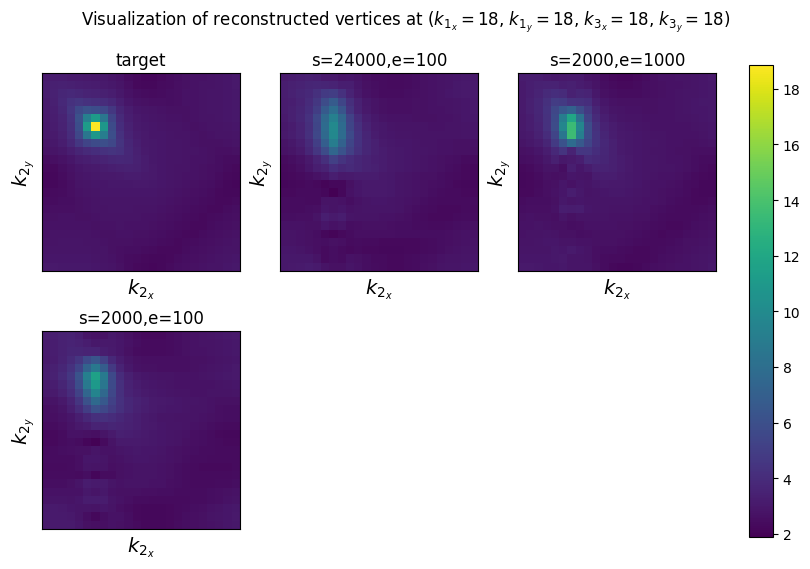

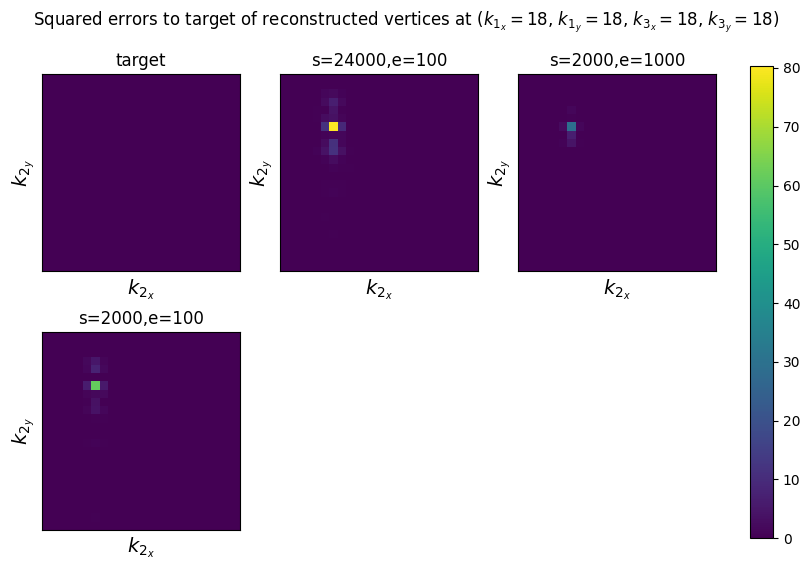

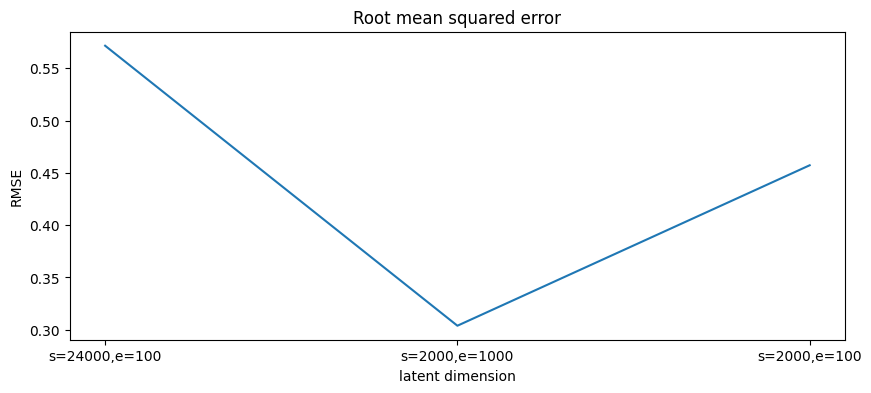

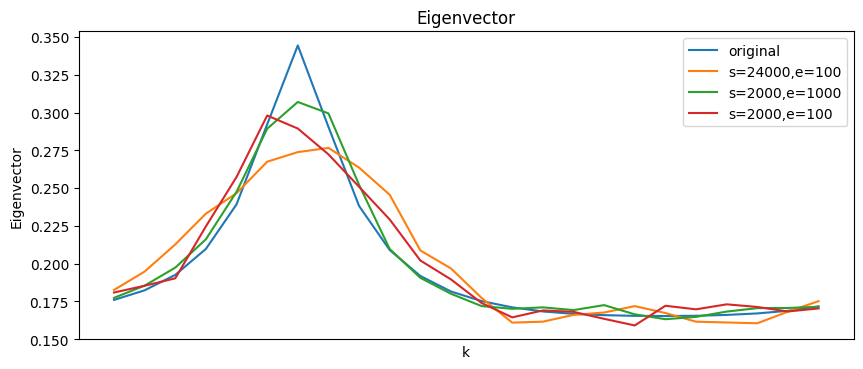

In [24]:
# RESULTS FOR 2-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i, i, i), axis, keys, nrows, ncols, 
                             trainer.predict_slice2d, fixed_idcs=(i, i, i, i))

### predict 576x576 slice

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_4/checkpoints\epoch=99-step=1900.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_4/checkpoints\epoch=99-step=1900.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_0/checkpoints\epoch=987-step=24700.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_0/checkpoints\epoch=987-step=24700.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_1/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_1/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=s=24000,e=100: RMSE=0.6087
   latent_dim=s=2000,e=1000: RMSE=0.3283
   latent_dim=s=2000,e=100: RMSE=0.4957


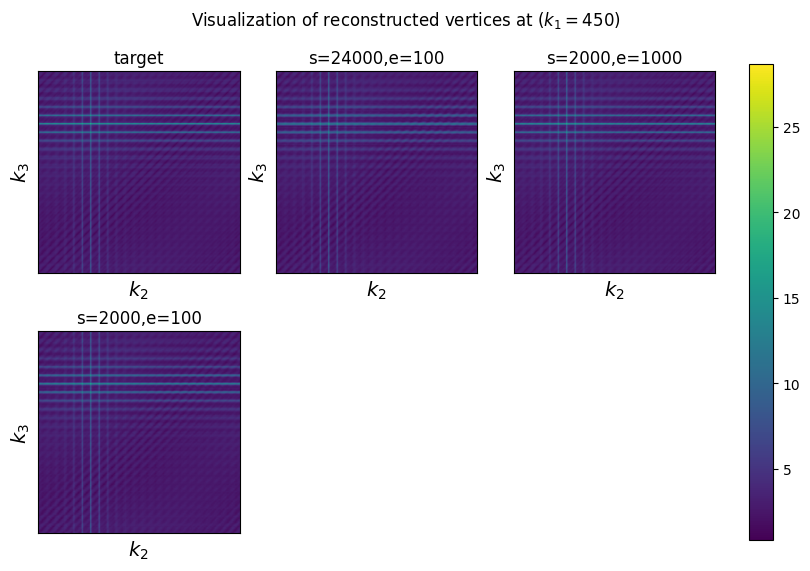

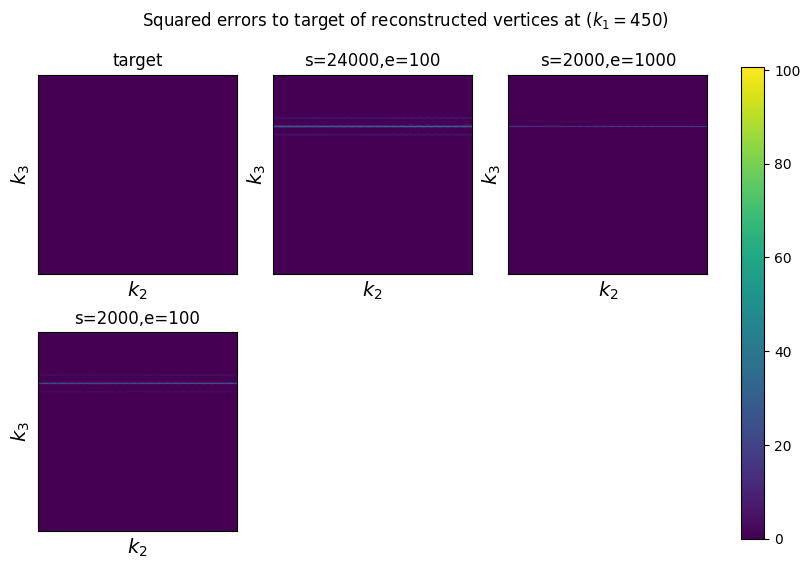

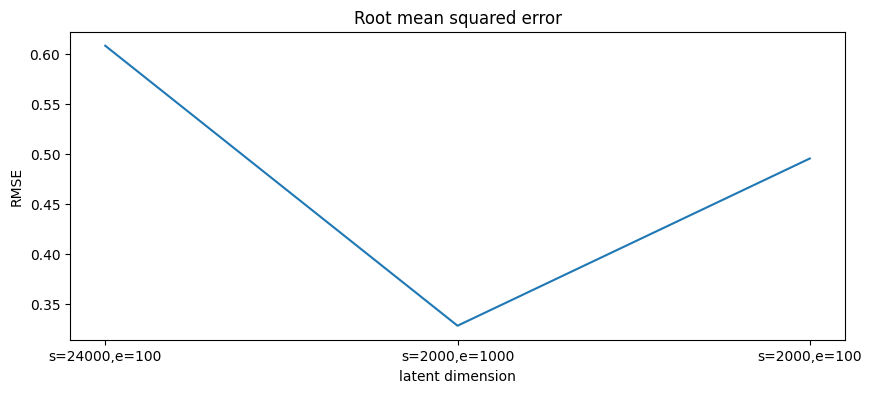

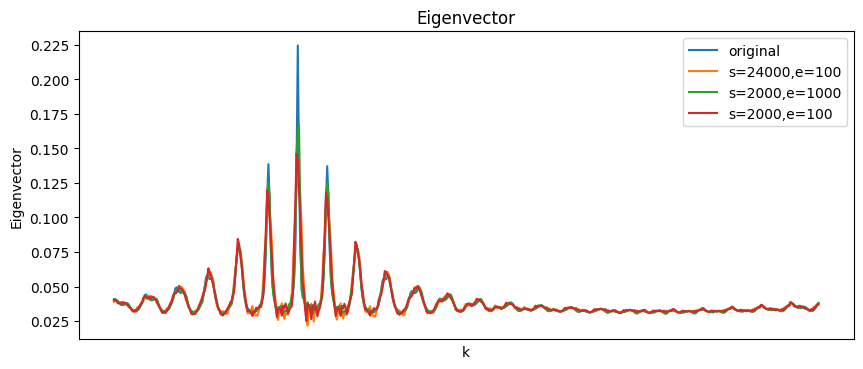

In [25]:
# RESULTS FOR 4-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i), (k, other_k), keys, nrows, ncols, 
                             trainer.predict_slice4d, fixed_idcs=(i, i), other_k=other_k)

### predict full vertex

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_4/checkpoints\epoch=99-step=1900.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS2048_2025-03-07/version_4/checkpoints\epoch=99-step=1900.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\loops\prediction_loop.py:255: predict returned None if it was on purpose, ignore this warning...
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_0/checkpoints\epoch=987-step=24700.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_0/checkpoints\epoch=987-step=24700.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_1/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_1/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=s=24000,e=100: RMSE=0.5889
   latent_dim=s=2000,e=1000: RMSE=0.1865
   latent_dim=s=2000,e=100: RMSE=0.5649


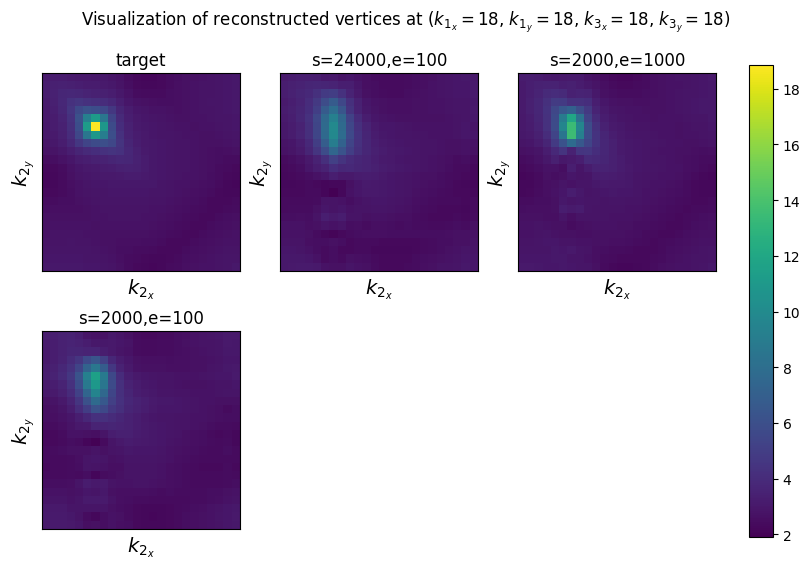

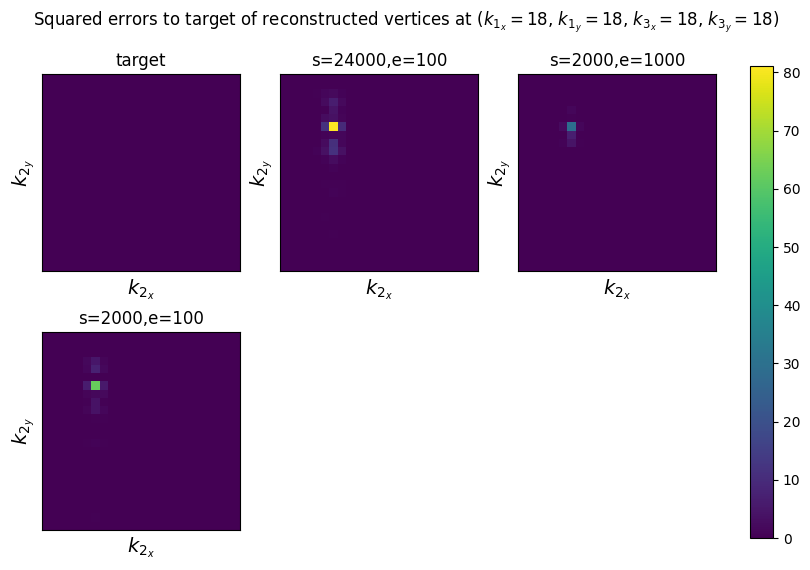

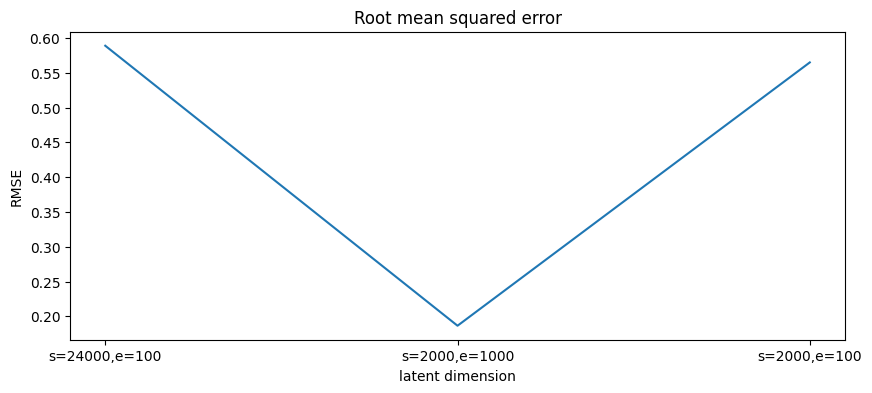

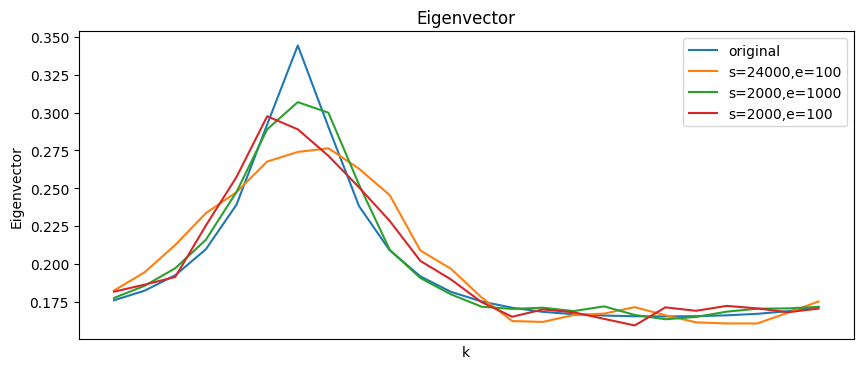

In [28]:
# RESULTS FOR 6-DIMENSIONAL PREDICTION
# for 6d-data
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

RESULTS:
   latent_dim=s=24000,e=100: RMSE=0.5889
   latent_dim=s=2000,e=1000: RMSE=0.1865
   latent_dim=s=2000,e=100: RMSE=0.5649


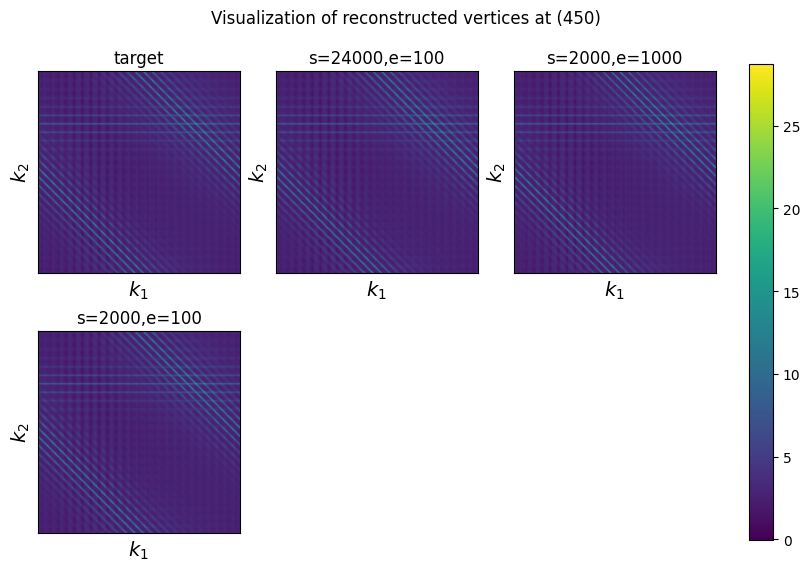

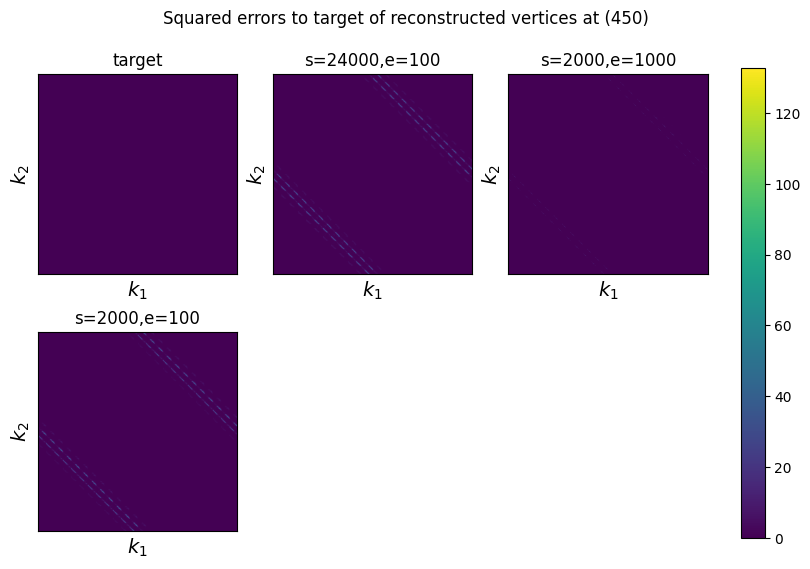

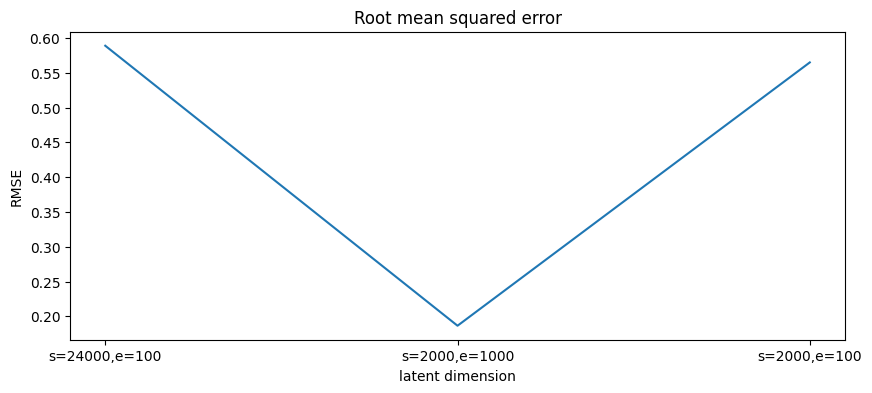

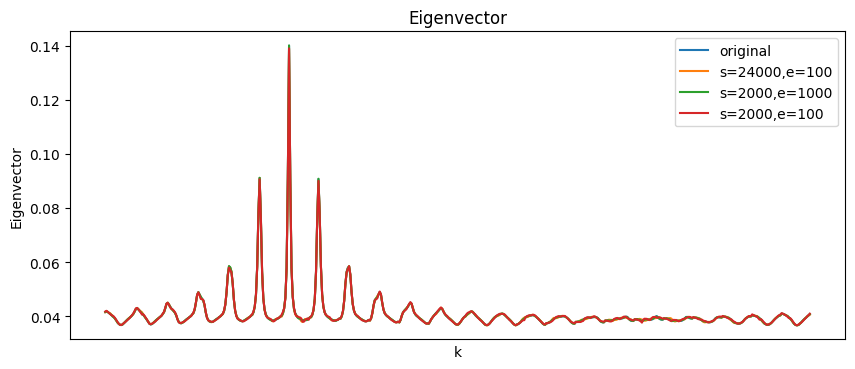

In [29]:
# for 3d-data
slice_at = slice_idx_3d
verteval.evaluate_and_report(info, test_file3d, trainer, vertex3, slice_at, axis, keys, nrows, ncols, 
                             load_func=trainer.load_prediction)

## correlation analysis

In [ ]:
cor_mat = verteval.vertex_correlation('../../../frgs_6d', pre_load_vertices=True)
vertvis.plot_correlation(cor_mat, "Vertex Correlation")

# 03 Latent dimension evaluation

* use most efficient sample- and epoch-count
* compare different layer sizes

In [3]:
info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'hidden_dims': [128, 64, 32],
                 'epochs': 100,
                 'sample_count_per_vertex': 2000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': False, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 4, 
                 'strategy': 'auto', 
                 'batch_size': 128}


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## train

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 64, 32])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-08\\version_0'

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 64, 32, 16])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07\\version_3'

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 64, 32, 8])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07\\version_4'

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, [128, 32, 16, 4])
# save_path='save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07\\version_5'

## evaluate prediction

In [9]:
test_file = 'tp0.020000_mu0.080000.h5'
test_file3d = '../../../frgs/' + test_file
test_file6d = '../../../frgs_6d/' + test_file

info = verteval.load_info_dict(info_fn)

vertex3 = AutoEncoderVertexDataset.load_from_file(test_file3d)
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)

keys = [f'n={x['latent_dim']}' for x in info]
trainer = init_trainer(device_type='cpu', batch_size=1024, num_dataloader_workers=8)

i = 18
axis = trainer.config.construction_axis
k, other_k = (axis + 1) // 2, 3
slice_idx_3d = i * 24 + i
nrows, ncols = 2, 3

### predict 24x24 slice

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\trainer\setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_2/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_2/checkpoints\epoch=99-step=2500.ckpt
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:424: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increa

Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\lightning\pytorch\loops\prediction_loop.py:255: predict returned None if it was on purpose, ignore this warning...
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_3/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_3/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_4/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_4/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_5/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_5/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=n=32: RMSE=0.5654
   latent_dim=n=16: RMSE=0.6835
   latent_dim=n=8: RMSE=0.7197
   latent_dim=n=4: RMSE=0.7827


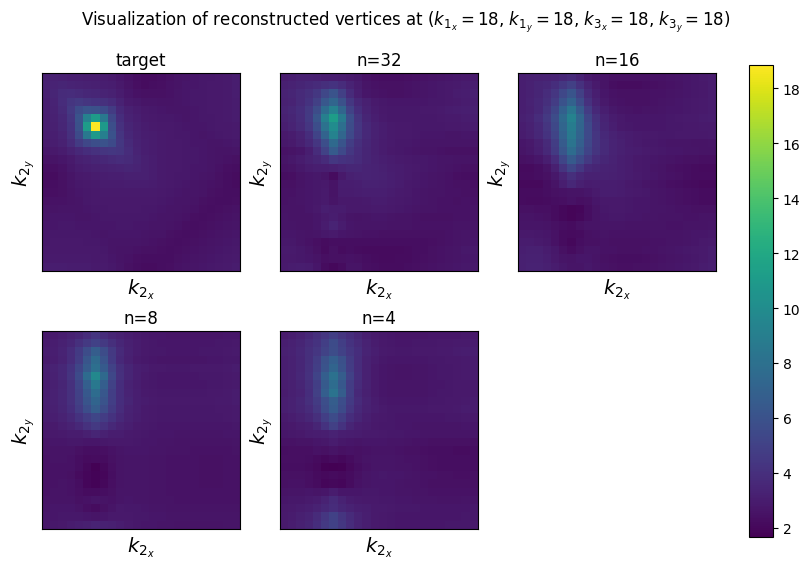

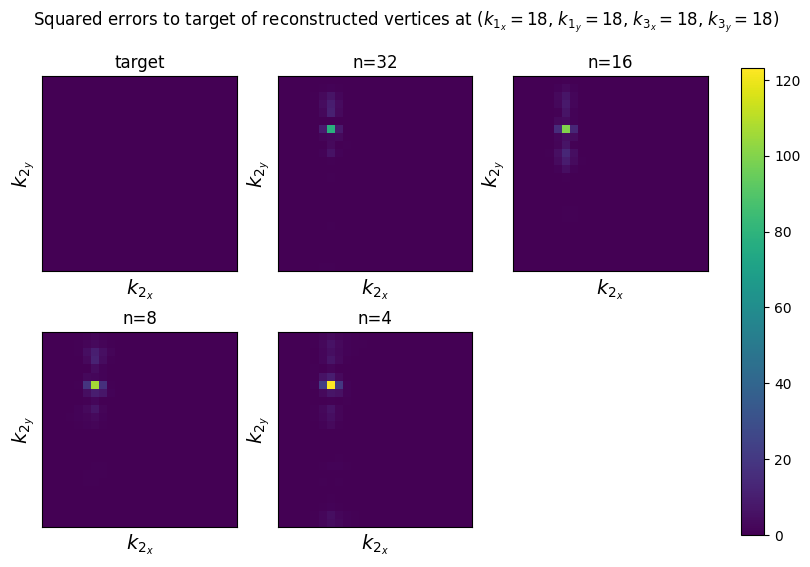

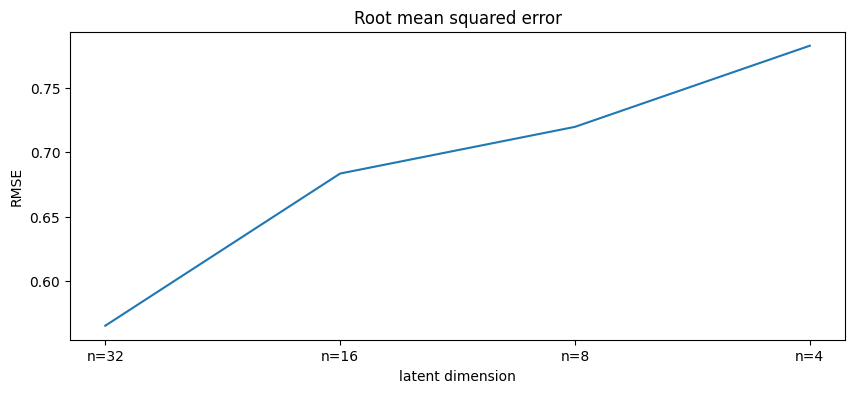

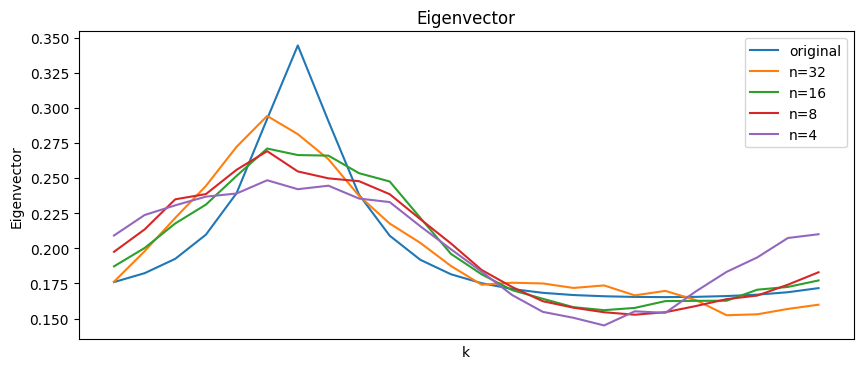

In [9]:
# RESULTS FOR 2-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i, i, i), axis, keys, nrows, ncols, 
                             trainer.predict_slice2d, fixed_idcs=(i, i, i, i))

### predict 576x576 slice

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_2/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_2/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_3/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_3/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_4/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_4/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Restoring states from the checkpoint path at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_5/checkpoints\epoch=99-step=2500.ckpt
Loaded model weights from the checkpoint at c:/OneDrive - TU Wien/Studium/Master_5. Semester/Masters thesis/code/PhysML/notebooks/vertex/../../saves/vertex_24x6/save_AUTO_ENCODER_VERTEX_24X6_BS128_2025-03-07/version_5/checkpoints\epoch=99-step=2500.ckpt


Predicting: |          | 0/? [00:00<?, ?it/s]

RESULTS:
   latent_dim=n=32: RMSE=0.6323
   latent_dim=n=16: RMSE=0.7722
   latent_dim=n=8: RMSE=0.7872
   latent_dim=n=4: RMSE=0.8965


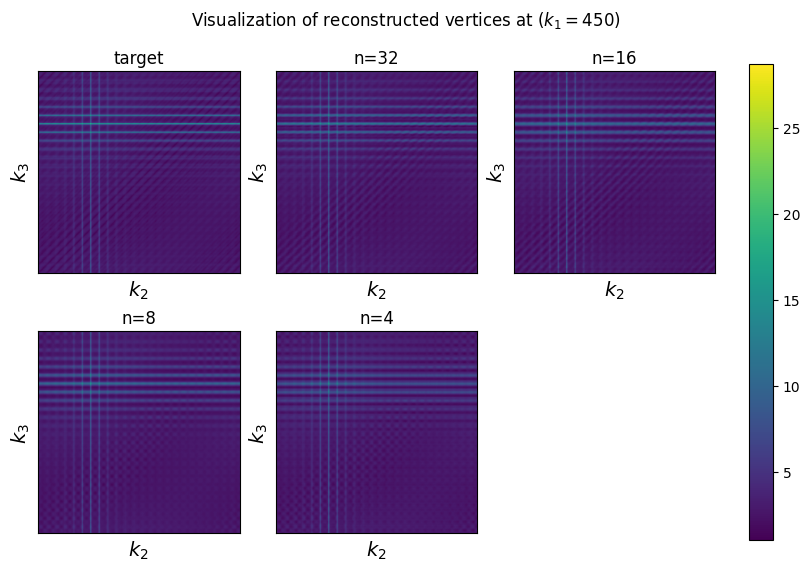

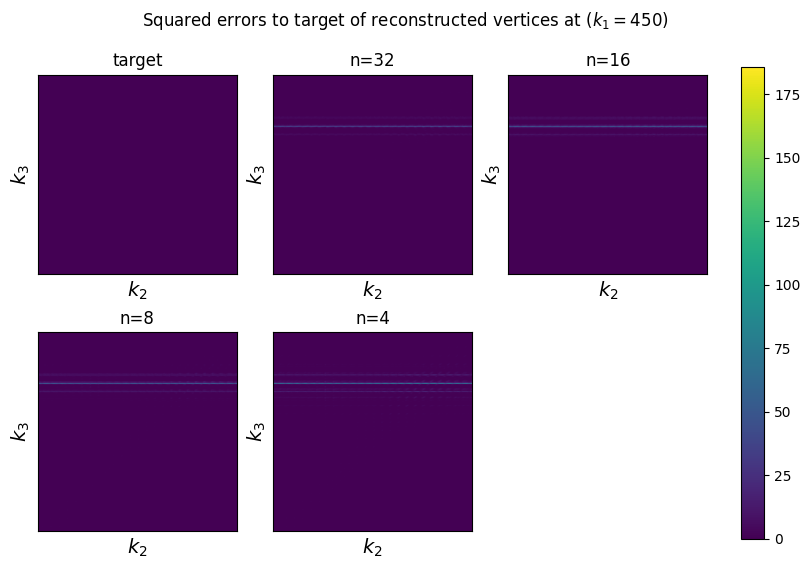

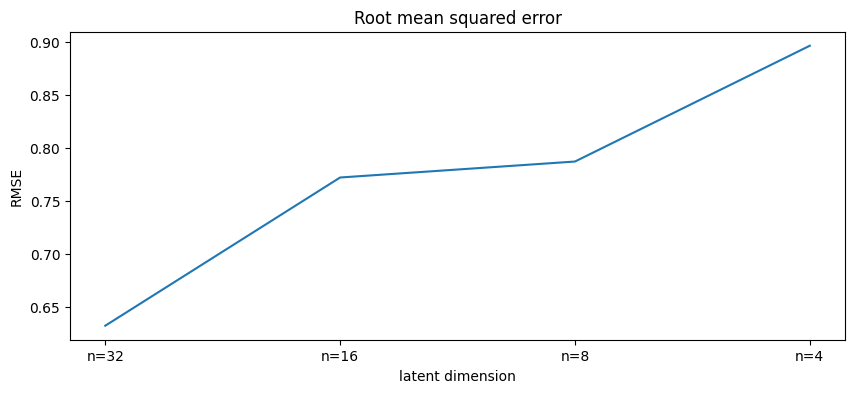

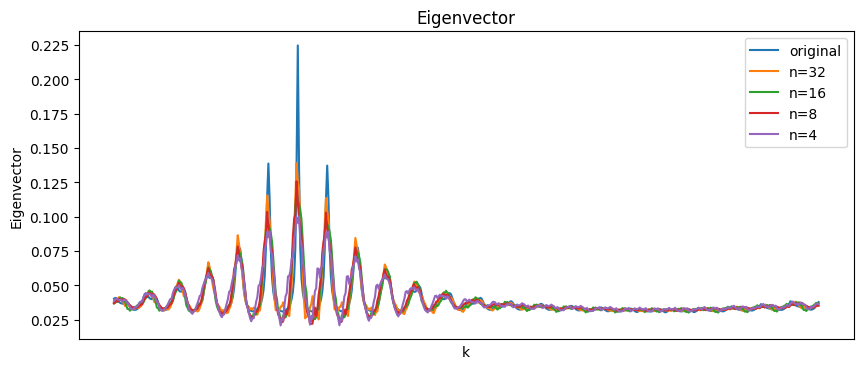

In [10]:
# RESULTS FOR 4-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i), (k, other_k), keys, nrows, ncols, 
                             trainer.predict_slice4d, fixed_idcs=(i, i), other_k=other_k)

### predict full vertex

In [ ]:
# RESULTS FOR 6-DIMENSIONAL PREDICTION
# for 6d-data
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

RESULTS:
   latent_dim=n=32: RMSE=0.6070
   latent_dim=n=16: RMSE=0.7612
   latent_dim=n=8: RMSE=1.1485
   latent_dim=n=4: RMSE=1.1400


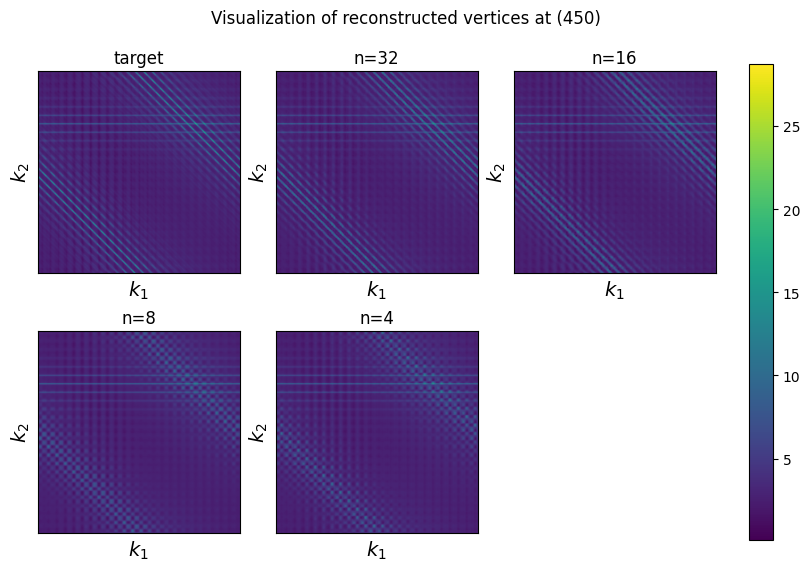

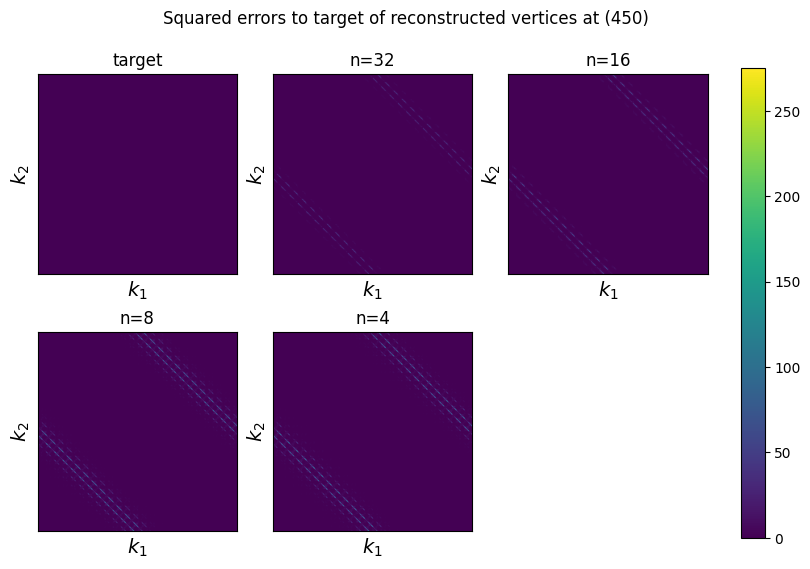

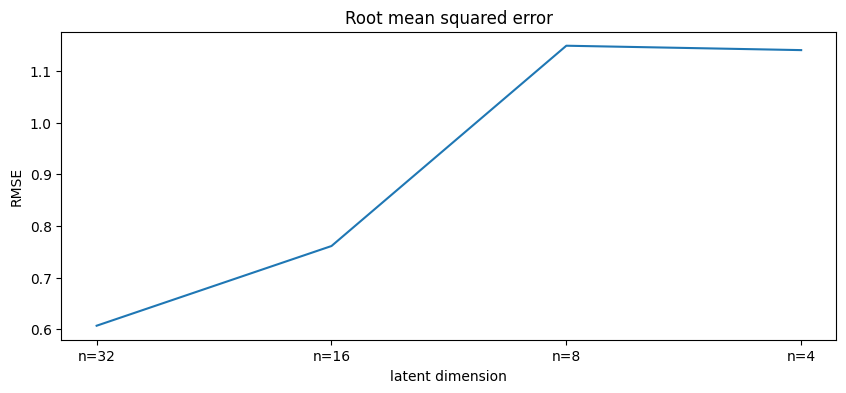

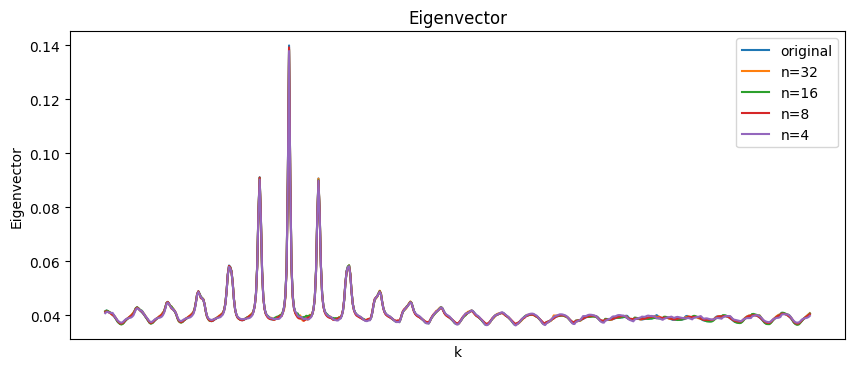

In [12]:
# for 3d-data
slice_at = slice_idx_3d
verteval.evaluate_and_report(info, test_file3d, trainer, vertex3, slice_at, axis, keys, nrows, ncols, 
                             load_func=trainer.load_prediction)

## correlation analysis

In [ ]:
cor_mat = verteval.vertex_correlation('../../../frgs_6d', pre_load_vertices=True)
vertvis.plot_correlation(cor_mat, "Vertex Correlation")

# 04 Phase classification

In [ ]:
from sklearn import ensemble, svm


info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32, 8]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'hidden_dims': hidden_dims,
                 'epochs': 100,
                 'sample_count_per_vertex': 2000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': True, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 4, 
                 'strategy': 'auto', 
                 'batch_size': 256}

seed = 12
pc_models = [
    # svm.SVC(random_state=seed + 1), 
    ensemble.RandomForestClassifier(n_jobs=-1, random_state=seed + 2),
]
train_samples_per_vertex = 200
test_samples_per_vertex = 100


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## 04-1 All vertices

* evaluate amount of information captured in latent space
* see how well the phase can be classified from the latent space

In [ ]:
trainer = init_trainer(subset=None)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [ ]:
save_path = trainer.config.save_path
pc = PhaseClassification(save_path, pc_models)

Model RandomForestClassifier is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [ ]:
pc.train(pc.vertex_trainer.dataset.file_paths, train_samples_per_vertex)

In [ ]:
model_scores = pc.evaluate_classifiers(pc.vertex_trainer.dataset.file_paths, test_samples_per_vertex, print_conf_mat=True)
with open(f'1_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)

## 04-2 Train/Test-split within each phase

* determine how well classification works for each phase

In [ ]:
trainer = init_trainer(subset=0.8, subset_type='phase')
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [14]:
trainer.config.save_path

'c:\\OneDrive - TU Wien\\Studium\\Master_5. Semester\\Masters thesis\\code\\PhysML\\notebooks\\vertex\\..\\..\\saves\\vertex_24x6\\save_AUTO_ENCODER_VERTEX_24X6_BS256_2025-03-19\\version_0'

In [ ]:
save_path = 'c:\\OneDrive - TU Wien\\Studium\\Master_5. Semester\\Masters thesis\\code\\PhysML\\notebooks\\vertex\\..\\..\\saves\\vertex_24x6\\save_AUTO_ENCODER_VERTEX_24X6_BS256_2025-03-19\\version_0'
pc = PhaseClassification(save_path, pc_models)

In [ ]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

Load data:   0%|          | 0/2 [00:00<?, ?it/s]

Fit models:   0%|          | 0/1 [00:00<?, ?it/s]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


In [ ]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'2_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)

## 04-3 Use vertices from SC-phase as test set

* determine how well the phase can be extrapolated from latent space

In [ ]:
trainer = init_trainer(subset=None, subset_type=['afm', 'fm'])
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [ ]:
save_path = 'c:\\OneDrive - TU Wien\\Studium\\Master_5. Semester\\Masters thesis\\code\\PhysML\\notebooks\\vertex\\..\\..\\saves\\vertex_24x6\\save_AUTO_ENCODER_VERTEX_24X6_BS256_2025-03-19\\version_7'
pc = PhaseClassification(save_path, pc_models)

In [ ]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

In [ ]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'3_phase_classification_results.pkl','wb') as f:
    pickle.dump(model_scores, f)

# 05 Phase regression

In [ ]:
st, se = 50, 12 * 60 +46
et, ee = None, 1000

(et - st) / (ee - se) * 1000

In [245]:
from sklearn import ensemble, svm


info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32, 8]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'hidden_dims': hidden_dims,
                 'epochs': 100,
                 'sample_count_per_vertex': 2000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': True, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 4, 
                 'strategy': 'auto', 
                 'batch_size': 256}

seed = 12
mode = 'r'
pc_models = [
    #svm.SVR(), 
    phase_classification.PolynomialRegression.new(degree=2),
    phase_classification.PolynomialRegression.new(degree=3),
    ensemble.RandomForestRegressor(n_jobs=-1, random_state=seed + 1),
]
train_samples_per_vertex = 200
test_samples_per_vertex = 100


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## 05-1 All vertices

In [ ]:
trainer = init_trainer(subset=None)
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [ ]:
save_path = trainer.config.save_path
pc = PhaseClassification(save_path, pc_models, mode)

In [ ]:
pc.train(pc.vertex_trainer.dataset.file_paths, train_samples_per_vertex)

In [ ]:
model_scores = pc.evaluate_classifiers(pc.vertex_trainer.dataset.file_paths, test_samples_per_vertex, print_conf_mat=True)
with open(f'1_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)

## 05-2 Train/Test-split within each phase

In [ ]:
trainer = init_trainer(subset=0.8, subset_type='phase')
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [246]:
save_path = 'c:\\OneDrive - TU Wien\\Studium\\Master_5. Semester\\Masters thesis\\code\\PhysML\\notebooks\\vertex\\..\\..\\saves\\vertex_24x6\\save_AUTO_ENCODER_VERTEX_24X6_BS256_2025-03-19\\version_0'
pc = PhaseClassification(save_path, pc_models, mode)

Model PolynomialRegression() is not fitted and could not be loaded. Call train() before using the PhaseClassifier.
Model PolynomialRegression(degree=3) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.
Model RandomForestRegressor(n_jobs=-1, random_state=13) is not fitted and could not be loaded. Call train() before using the PhaseClassifier.


In [247]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

Load data:   0%|          | 0/2 [00:00<?, ?it/s]

Fit models:   0%|          | 0/3 [00:00<?, ?it/s]

Predict:   0%|          | 0/3 [00:00<?, ?it/s]

Load data:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


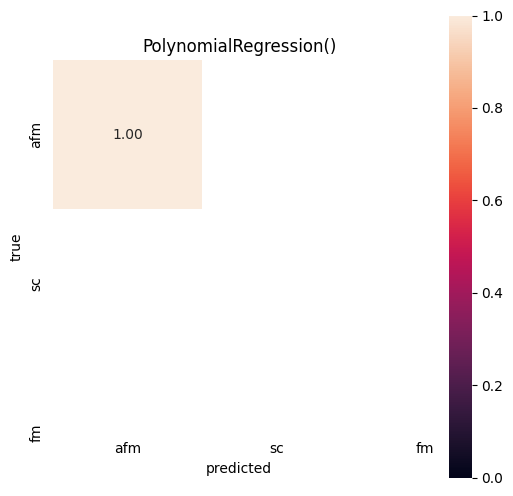

Load data:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


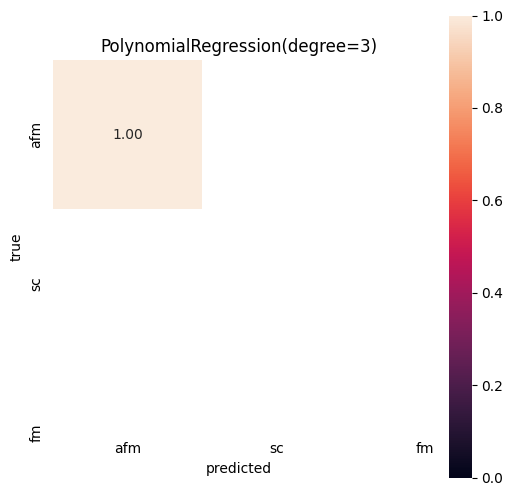

Load data:   0%|          | 0/1 [00:00<?, ?it/s]

c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
c:\Users\Sebastian\venv\ml24_1\Lib\site-packages\sklearn\metrics\_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


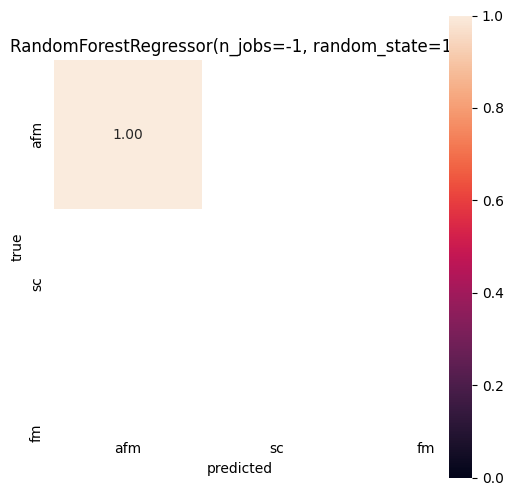

In [ ]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'2_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)

## 05-3 Use vertices from SC-phase as test set

In [ ]:
trainer = init_trainer(subset=None, subset_type=['afm', 'fm'])
verteval.eval_train(trainer, info, info_fn, hidden_dims)

In [ ]:
trainer.config.save_path

In [ ]:
save_path = 'c:\\OneDrive - TU Wien\\Studium\\Master_5. Semester\\Masters thesis\\code\\PhysML\\notebooks\\vertex\\..\\..\\saves\\vertex_24x6\\save_AUTO_ENCODER_VERTEX_24X6_BS256_2025-03-19\\version_7'
pc = PhaseClassification(save_path, pc_models, mode)

In [ ]:
path_train = '../../../frgs_6d'
train_files = pc.vertex_trainer.dataset.file_paths
test_files = [f for f in glob.glob(f"{path_train}/*.h5") if f not in train_files]
pc.train(train_files, train_samples_per_vertex)

In [ ]:
model_scores = pc.evaluate_classifiers(test_files, test_samples_per_vertex, print_conf_mat=True)
with open(f'3_phase_regression_results.pkl','wb') as f:
    pickle.dump(model_scores, f)

# 0x U-Net

* only for full prediction  
  (latent space alone is useless, since decoder needs inputs from skip connections)

In [13]:
info_fn = 'eval_info_test.pkl'
info = verteval.load_info_dict(info_fn)
hidden_dims = [128, 64, 32]
config_kwargs = {'path_train': '../../../frgs_6d', 
                 'model_name': 'UNetVertex',
                 'hidden_dims': hidden_dims,
                 'epochs': 1000,
                 'sample_count_per_vertex': 2000, 
                 'test_ratio': 0.2, 
                 'subset': -1, 
                 'subset_shuffle': False, 
                 'devices': 'auto', 
                 'num_dataloader_workers': 4, 
                 'strategy': 'auto', 
                 'batch_size': 2048}


def init_trainer(device_type: Literal['cpu', 'gpu'] = 'gpu', **kwargs) -> VertexTrainer24x6:
    config_kwargs['device_type'] = device_type
    for k, v in kwargs.items():
        config_kwargs[k] = v
    trainer = VertexTrainer24x6(project_name='vertex_24x6', config_name='confmod_auto_encoder.json', 
                                subconfig_name='AUTO_ENCODER_VERTEX_24X6', 
                                config_kwargs=config_kwargs)
    return trainer

## train

In [ ]:
trainer = init_trainer()
verteval.eval_train(trainer, info, info_fn, hidden_dims)

## evaluate prediction

In [ ]:
test_file = 'tp0.020000_mu0.080000.h5'
test_file3d = '../../../frgs/' + test_file
test_file6d = '../../../frgs_6d/' + test_file

info = verteval.load_info_dict(info_fn)

vertex3 = AutoEncoderVertexDataset.load_from_file(test_file3d)
vertex6 = AutoEncoderVertex24x6Dataset.load_from_file(test_file6d)

keys = [f'n={x['latent_dim']}' for x in info]
trainer = init_trainer(device_type='cpu', batch_size=1024, num_dataloader_workers=8)

i = 18
axis = trainer.config.construction_axis
k, other_k = (axis + 1) // 2, 3
slice_idx_3d = i * 24 + i
nrows, ncols = 2, 3

### predict 24x24 slice

In [ ]:
# RESULTS FOR 2-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i, i, i), axis, keys, nrows, ncols, 
                             trainer.predict_slice2d, fixed_idcs=(i, i, i, i))

### predict 576x576 slice

In [ ]:
# RESULTS FOR 4-DIMENSIONAL PREDICTION
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, (i, i), (k, other_k), keys, nrows, ncols, 
                             trainer.predict_slice4d, fixed_idcs=(i, i), other_k=other_k)

### predict full vertex

In [ ]:
# RESULTS FOR 6-DIMENSIONAL PREDICTION
# for 6d-data
slice_at = (i, i, i, i)
verteval.evaluate_and_report(info, test_file6d, trainer, vertex6, slice_at, axis, keys, nrows, ncols, 
                             predict_func=trainer.predict)

In [ ]:
# for 3d-data
slice_at = slice_idx_3d
verteval.evaluate_and_report(info, test_file3d, trainer, vertex3, slice_at, axis, keys, nrows, ncols, 
                             load_func=trainer.load_prediction)

# ---